In [45]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
file = pd.read_csv('online_learning.csv')
file.head()

,student_id,course_category,login_frequency_per_week,avg_session_minutes,course_progress_percent,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent,device_type,dropout_risk
0,1,Design,14,17,51,7,60.42,14,23,Desktop,Low
1,2,AI & ML,8,26,1,10,77.25,33,29,Tablet,Medium
2,3,Business,6,26,24,1,93.46,23,82,Desktop,Low
3,4,AI & ML,5,99,12,7,69.77,32,92,Desktop,Low
4,5,AI & ML,13,150,97,3,89.48,40,34,Tablet,Low


In [47]:
risk_mapping = {
    'Low': 0,
    'Medium': 0.5,
    'High': 1}

file['dropout_risk_numeric'] = file['dropout_risk'].map(risk_mapping)
file.head()

,student_id,course_category,login_frequency_per_week,avg_session_minutes,course_progress_percent,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent,device_type,dropout_risk,dropout_risk_numeric
0,1,Design,14,17,51,7,60.42,14,23,Desktop,Low,0.0
1,2,AI & ML,8,26,1,10,77.25,33,29,Tablet,Medium,0.5
2,3,Business,6,26,24,1,93.46,23,82,Desktop,Low,0.0
3,4,AI & ML,5,99,12,7,69.77,32,92,Desktop,Low,0.0
4,5,AI & ML,13,150,97,3,89.48,40,34,Tablet,Low,0.0


In [48]:
file.isnull().sum()

student_id                  0
course_category             0
login_frequency_per_week    0
avg_session_minutes         0
course_progress_percent     0
assignments_completed       0
quiz_average_score          0
forum_interactions          0
video_watch_percent         0
device_type                 0
dropout_risk                0
dropout_risk_numeric        0
dtype: int64

In [49]:
print('Общий портрет аудитории')
print('Распределение по ключевым категорям датасета')
print('1. Анализ рисков отсева:')
count_risk = file.groupby('dropout_risk')['student_id'].count()
print(count_risk)

Общий портрет аудитории
Распределение по ключевым категорям датасета
1. Анализ рисков отсева:
dropout_risk
High       593
Low       1360
Medium     847
Name: student_id, dtype: int64


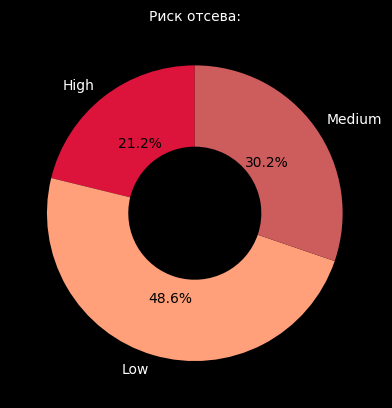

In [50]:
labels = ['High', 'Low', 'Medium']
plt.title('Риск отсева:', fontsize = '10')
colors = ['#DC143C', '#FFA07A', '#CD5C5C']
wedges, texts, autotexts = plt.pie(count_risk, labels=labels,wedgeprops=dict(width=0.55), colors = colors, autopct='%1.1f%%', startangle = 90)
for autotext in autotexts:
    autotext.set_color('black')
plt.show()

In [51]:
risk = file.groupby('dropout_risk').agg(
    task_completed = ('assignments_completed', 'sum'),
    AVG_score = ('quiz_average_score', 'mean'),
    percent_wath= ('video_watch_percent', 'mean'))
risk = risk.round(2)
risk = risk.sort_values(by='task_completed', ascending=False)
print(risk)

              task_completed  AVG_score  percent_wath
dropout_risk                                         
Low                     7657      69.70         60.36
Medium                  4674      70.21         60.61
High                    3385      71.01         59.54


In [52]:
print('2. Распределение аудитории по устройствам:')
count_device = file.groupby('device_type')['student_id'].count()
print(count_device)

2. Распределение аудитории по устройствам:
device_type
Desktop    957
Mobile     919
Tablet     924
Name: student_id, dtype: int64


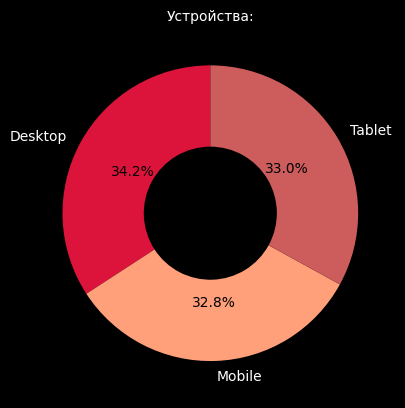

In [53]:
labels = ['Desktop', 'Mobile', 'Tablet']
plt.title('Устройства:', fontsize = '10')
colors = ['#DC143C', '#FFA07A', '#CD5C5C']
wedges, texts, autotexts = plt.pie(count_device, labels=labels,wedgeprops=dict(width=0.55), colors = colors, autopct='%1.1f%%', startangle = 90)
for autotext in autotexts:
    autotext.set_color('black')
plt.show()

In [54]:
print('Количество сессий и частота:')
device = file.groupby('device_type').agg(
    session = ('avg_session_minutes', 'mean'),
    login_frequncy = ('login_frequency_per_week', 'mean'))
device = device.round(2)
print(device)

Количество сессий и частота:
             session  login_frequncy
device_type                         
Desktop        94.05            7.58
Mobile         95.86            7.47
Tablet         92.81            7.43


In [55]:
print('Показатели по категориям курсов')
print('1. По категории курса:')

result = file.groupby('course_category').agg(
    students_count = ('student_id', 'count'),
    total_time = ('avg_session_minutes', 'sum'))
sort_result = result.sort_values(by='total_time', ascending=False)
sort_result = sort_result.round({'login_frequncy':2})
print(sort_result)

Показатели по категориям курсов
1. По категории курса:
                 students_count  total_time
course_category                            
Data Science                567       54721
AI & ML                     567       53906
Design                      581       53896
Programming                 557       50759
Business                    528       50581


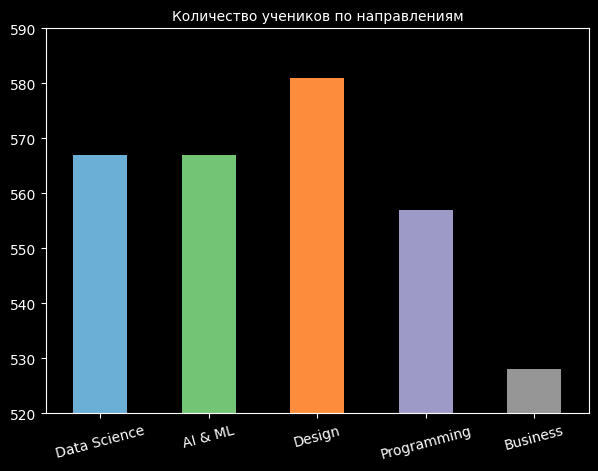

In [67]:
colors = ['#6baed6','#74c476', '#fd8d3c', '#9e9ac8', '#969696']
sort_result['students_count'].plot(kind='bar', figsize=(7, 5), color = colors)

plt.title('Количество учеников по направлениям', fontsize = '10')
plt.xlabel('')
plt.ylim(520,590)
plt.xticks(rotation=15)
plt.show()

In [57]:
print('2. Средний балл тестов по курсам:')
avg_score_courses = file.groupby('course_category')['quiz_average_score'].mean().round(1)
print(avg_score_courses)

2. Средний балл тестов по курсам:
course_category
AI & ML         70.6
Business        70.3
Data Science    70.4
Design          69.2
Programming     70.1
Name: quiz_average_score, dtype: float64


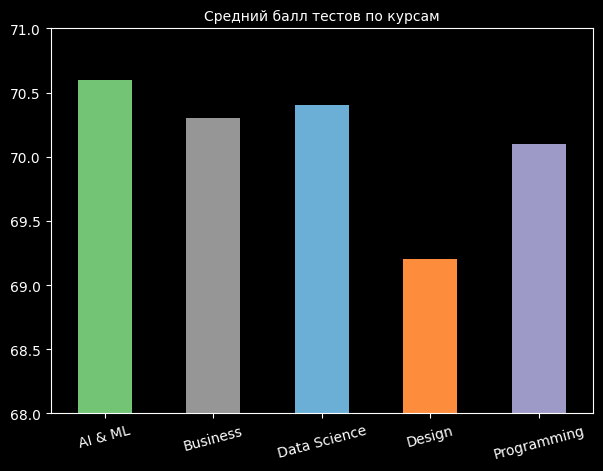

In [58]:
colors = ['#74c476','#969696', '#6baed6', '#fd8d3c', '#9e9ac8']
avg_score_courses.plot(kind='bar', figsize=(7, 5), color = colors)
plt.title('Средний балл тестов по курсам', fontsize = '10')

plt.ylim(68,71)
plt.xlabel('')
plt.xticks(rotation=15)
plt.show()

In [59]:
print('3. Прогресс курса по направлениям:')
progress_courses = file.groupby('course_category')['course_progress_percent'].mean().round(1)
print(progress_courses)

3. Прогресс курса по направлениям:
course_category
AI & ML         51.6
Business        49.7
Data Science    50.5
Design          50.7
Programming     50.4
Name: course_progress_percent, dtype: float64


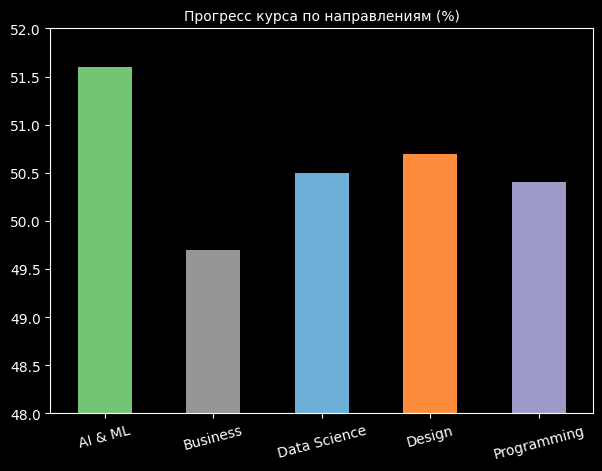

In [68]:
colors = ['#74c476','#969696', '#6baed6', '#fd8d3c', '#9e9ac8']
progress_courses.plot(kind='bar', figsize=(7, 5), color = colors)
plt.title('Прогресс курса по направлениям (%)', fontsize = '10')

plt.ylim(48,52)
plt.xlabel('')
plt.xticks(rotation=15)
plt.show()

In [61]:
print('Риск отсева по категориям')
risk_by_category = file.groupby('course_category')['dropout_risk'].value_counts(normalize=True).mul(100).round(1)
print(risk_by_category)

Риск отсева по категориям
course_category  dropout_risk
AI & ML          Low             51.7
                 Medium          28.9
                 High            19.4
Business         Low             49.8
                 Medium          29.0
                 High            21.2
Data Science     Low             48.7
                 Medium          27.9
                 High            23.5
Design           Low             44.9
                 Medium          31.2
                 High            23.9
Programming      Low             47.9
                 Medium          34.3
                 High            17.8
Name: proportion, dtype: float64


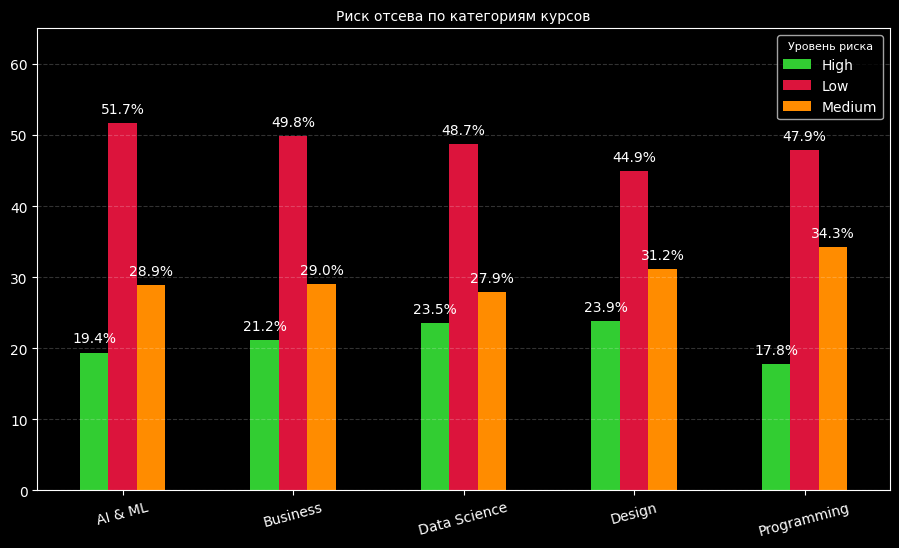

In [62]:
risk_pivot = risk_by_category.unstack()
fig, ax = plt.subplots(figsize=(11, 6))
risk_pivot.plot(kind='bar', ax=ax, color=['#32CD32', '#DC143C', '#FF8C00'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

ax.set_xlabel('')
ax.set_title('Риск отсева по категориям курсов', fontsize=10)
ax.legend(title='Уровень риска', title_fontsize=8, loc = 'best')
ax.set_ylim(0, 65)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)
plt.xticks(rotation=15)
plt.show()

In [63]:
print('Профиль студентов по группам рисков:')
profile_group_risk = file.groupby('dropout_risk').agg(
    logins_week =('login_frequency_per_week', 'mean'),
    session_min = ('avg_session_minutes', 'mean'),
    progress = ('course_progress_percent', 'mean'),
    task_complete = ('assignments_completed', 'mean'),
    avg_score = ('quiz_average_score', 'mean'),
    forum = ('forum_interactions', 'mean'),
    watch = ('video_watch_percent', 'mean'))
profile_group_risk = profile_group_risk.round(1)
print(profile_group_risk)

Профиль студентов по группам рисков:
              logins_week  session_min  progress  task_complete  avg_score  \
dropout_risk                                                                 
High                  7.4         93.6      53.2            5.7       71.0   
Low                   7.5         94.3      50.0            5.6       69.7   
Medium                7.5         94.6      49.8            5.5       70.2   

              forum  watch  
dropout_risk                
High           24.1   59.5  
Low            24.8   60.4  
Medium         24.7   60.6  


In [64]:
print('Связь метрик с риском отсева')
numeric_cols = file.select_dtypes(include=['number']).columns
correlations = file[numeric_cols].corrwith(file['dropout_risk_numeric'])
correlations = correlations.drop('dropout_risk_numeric', errors='ignore')
correlations = correlations.drop('student_id', errors='ignore')
print(correlations)

Связь метрик с риском отсева
login_frequency_per_week   -0.010845
avg_session_minutes        -0.003982
course_progress_percent     0.037307
assignments_completed       0.004344
quiz_average_score          0.028904
forum_interactions         -0.018362
video_watch_percent        -0.010901
dtype: float64


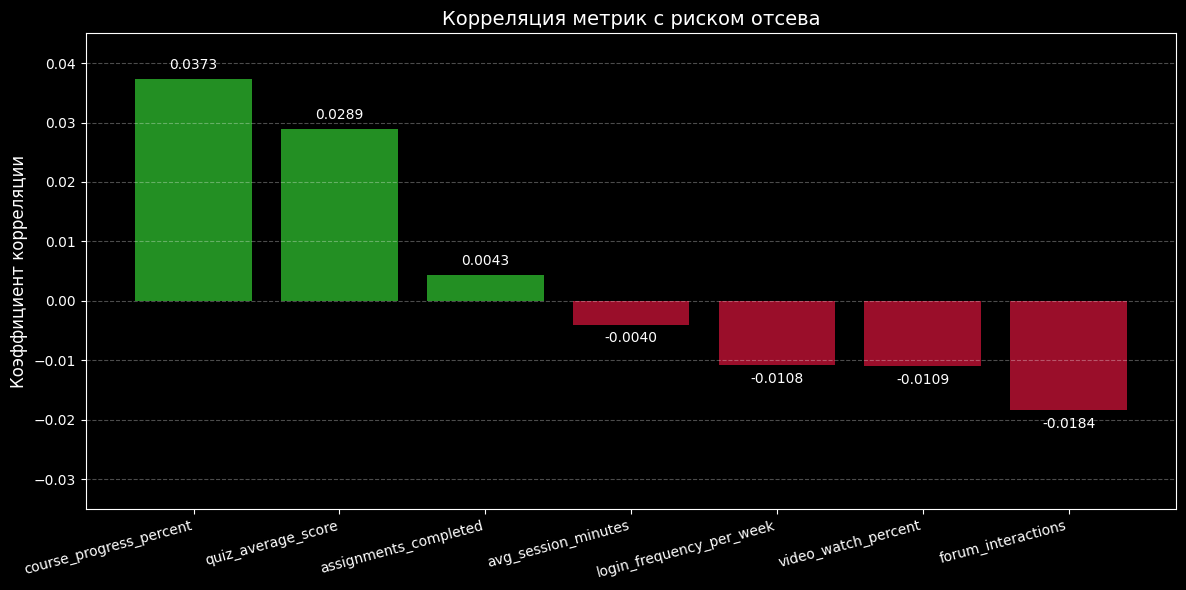

In [65]:
fig, ax = plt.subplots(figsize=(12, 6))

correlations_sorted = correlations.sort_values(ascending=False)
colors = ['#DC143C' if x < 0 else '#32CD32' for x in correlations_sorted.values]
bars = ax.bar(range(len(correlations_sorted)), correlations_sorted.values, color=colors, alpha=0.7)

ax.set_xticks(range(len(correlations_sorted)))
ax.set_xticklabels(correlations_sorted.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Коэффициент корреляции', fontsize=12)
ax.set_title('Корреляция метрик с риском отсева', fontsize=12)
ax.set_ylim(-0.035,0.045)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt ='%.4f', padding=5)

plt.tight_layout()
plt.show()